# Navier-Stokes Uncertainty Data — Loading Guide

This notebook shows how to load and visualize every kind of data in this folder:

1. Reference solution (`DATA_observations/reference_t100.npz`)
2. Experiment summary table (`DATA_observations/summary.csv`)
3. Observations (noisy / biased inputs used for training) — `DATA_observations/`
4. One exported model's predicted fields — `DATA_per_model_t100/<run_name>/`
5. Mapping: run → observation scenario

All data is at time slice **t_idx = 100 (t = 10.0)**. All arrays are `(50, 100)` `float32`.

## What is `loss_weight`?

$$\mathcal{L} = \alpha \cdot \mathcal{L}_{\text{data}} + (1 - \alpha) \cdot \mathcal{L}_{\text{PDE}}$$

where $\alpha$ = `loss_weight`.

| loss_weight | Meaning |
|-------------|---------|
| 0.0 | Pure PDE, no data |
| 0.5 | Balanced |
| 1.0 | Pure data, no PDE |

## Directory structure

```
Navier_Stokes_unsteady/
├── DATA_observations/         # reference + summary + 8 observation scenarios
│   ├── reference_t100.npz     # shared reference solution + grid
│   ├── summary.csv            # config for all 40 runs
│   └── <scenario>.npz         # clean + noise/bias variants
└── DATA_per_model_t100/       # 40 runs, one folder each with psi/u/v/pressure
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path('.').resolve()

## 1. Load reference solution

Grid: (50, 100), t = 10.0


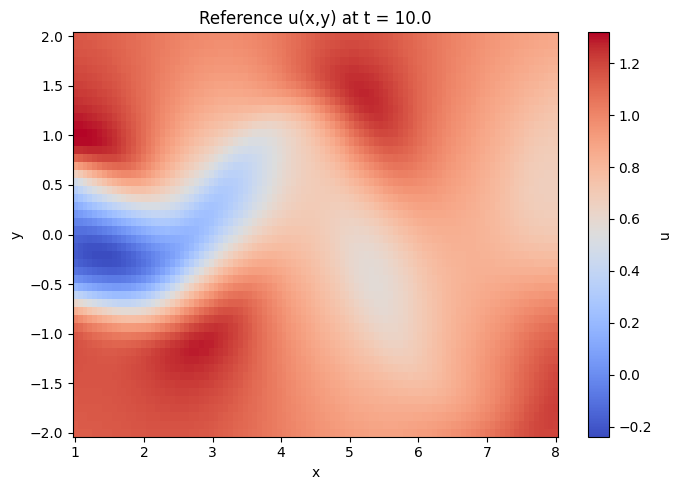

In [2]:
ref = np.load(DATA_DIR / 'DATA_observations' / 'reference_t100.npz')

x_grid = ref['x_grid']    # (50, 100) spatial x
y_grid = ref['y_grid']    # (50, 100) spatial y
u_ref  = ref['u_ref']     # (50, 100) reference u velocity
v_ref  = ref['v_ref']     # (50, 100) reference v velocity
p_ref  = ref['p_ref']     # (50, 100) reference pressure
t_value = float(ref['t_value'])  # 10.0

print(f'Grid: {x_grid.shape}, t = {t_value}')

plt.figure(figsize=(7, 5))
plt.pcolormesh(x_grid, y_grid, u_ref, shading='auto', cmap='coolwarm')
plt.colorbar(label='u'); plt.xlabel('x'); plt.ylabel('y')
plt.title(f'Reference u(x,y) at t = {t_value:.1f}')
plt.tight_layout(); plt.show()

## 2. Load summary table

`summary.csv` holds the config of every run: `run_name`, `scenario`, `loss_weight`, `pde_weight`, `noise_type`, `noise_level`, `bias_type`, `bias_level`.

In [3]:
summary = pd.read_csv(DATA_DIR / 'DATA_observations' / 'summary.csv')
summary.head(10)

,run_name,scenario,loss_weight,pde_weight,noise_type,noise_level,bias_type,bias_level,rel_l2_u,rel_l2_v,rel_l2_p,adam_steps,n_train
0,lw_0p000,clean,0.0,1.0,none,0.00,none,0.0,0.999008,0.999981,0.781048,10000,5000
1,lw_0p000_cosine_0p300,bias_cosine_0p300,0.0,1.0,none,0.00,cosine,0.3,0.999008,0.999981,0.781048,10000,5000
2,lw_0p000_cosine_0p500,bias_cosine_0p500,0.0,1.0,none,0.00,cosine,0.5,0.999008,0.999981,0.781048,10000,5000
3,lw_0p000_cosine_0p800,bias_cosine_0p800,0.0,1.0,none,0.00,cosine,0.8,0.999008,0.999981,0.781048,10000,5000
4,lw_0p000_gaussian_0p050,noise_gaussian_0p050,0.0,1.0,gaussian,0.05,none,0.0,0.999008,0.999981,0.781048,10000,5000
5,lw_0p000_gaussian_0p050_cosine_0p300,noise_gaussian_0p050__bias_cosine_0p300,0.0,1.0,gaussian,0.05,cosine,0.3,0.999008,0.999981,0.781048,10000,5000
6,lw_0p000_gaussian_0p050_cosine_0p500,noise_gaussian_0p050__bias_cosine_0p500,0.0,1.0,gaussian,0.05,cosine,0.5,0.999008,0.999981,0.781048,10000,5000
7,lw_0p000_gaussian_0p050_cosine_0p800,noise_gaussian_0p050__bias_cosine_0p800,0.0,1.0,gaussian,0.05,cosine,0.8,0.999008,0.999981,0.781048,10000,5000
8,lw_0p200,clean,0.2,0.8,none,0.00,none,0.0,0.053361,0.219377,0.324369,10000,5000
9,lw_0p200_cosine_0p300,bias_cosine_0p300,0.2,0.8,none,0.00,cosine,0.3,0.116507,0.310774,1.671379,10000,5000


## 3. Load an observation

Each file in `DATA_observations/` contains:

| Key | Shape | Description |
|-----|-------|-------------|
| `u_obs` | (50,100) | observed u (with noise/bias) |
| `v_obs` | (50,100) | observed v (with noise/bias) |

Scenarios: `clean`, `noise_gaussian_0p050`, `bias_cosine_0p{300,500,800}`, `noise_gaussian_0p050__bias_cosine_0p{300,500,800}`.

u_obs shape: (50, 100), dtype: float32


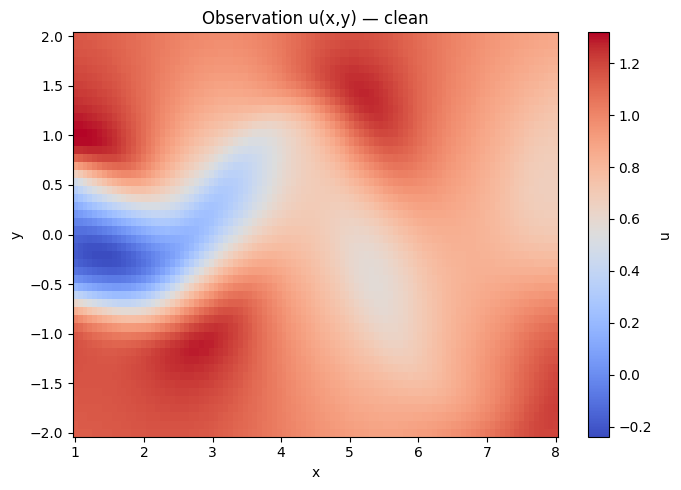

In [4]:
obs = np.load(DATA_DIR / 'DATA_observations' / 'clean.npz')

u_obs = obs['u_obs']  # (50, 100)
v_obs = obs['v_obs']  # (50, 100)

print(f'u_obs shape: {u_obs.shape}, dtype: {u_obs.dtype}')

plt.figure(figsize=(7, 5))
plt.pcolormesh(x_grid, y_grid, u_obs, shading='auto', cmap='coolwarm',
               vmin=u_ref.min(), vmax=u_ref.max())
plt.colorbar(label='u'); plt.xlabel('x'); plt.ylabel('y')
plt.title('Observation u(x,y) — clean')
plt.tight_layout(); plt.show()

## 4. Load one exported model (prediction)

Each run folder in `DATA_per_model_t100/` contains four files:

| File | Key | Description |
|------|-----|-------------|
| `psi_t100.npz` | `values` | stream function ψ |
| `u_t100.npz` | `values` | predicted u |
| `v_t100.npz` | `values` | predicted v |
| `pressure_t100.npz` | `values` | predicted pressure |

Each file also carries `x_grid`, `y_grid`, `t_value`, `run_name`.

In [5]:
data_root = DATA_DIR / 'DATA_per_model_t100'
model_dirs = sorted([p for p in data_root.iterdir() if p.is_dir()])
model_dir = model_dirs[20]

psi_data = np.load(model_dir / 'psi_t100.npz')
u_data = np.load(model_dir / 'u_t100.npz')
pressure_data = np.load(model_dir / 'pressure_t100.npz')

psi = psi_data['values']
u = u_data['values']
pressure = pressure_data['values']
x_grid = psi_data['x_grid']
y_grid = psi_data['y_grid']
t_value = float(psi_data['t_value'])

print('model_name =', model_dir.name)
print('t_value    =', t_value)
print('psi shape   =', psi.shape)
print('u shape     =', u.shape)
print('p shape     =', pressure.shape)

model_name = lw_0p500_gaussian_0p050
t_value    = 10.0
psi shape   = (50, 100)
u shape     = (50, 100)
p shape     = (50, 100)


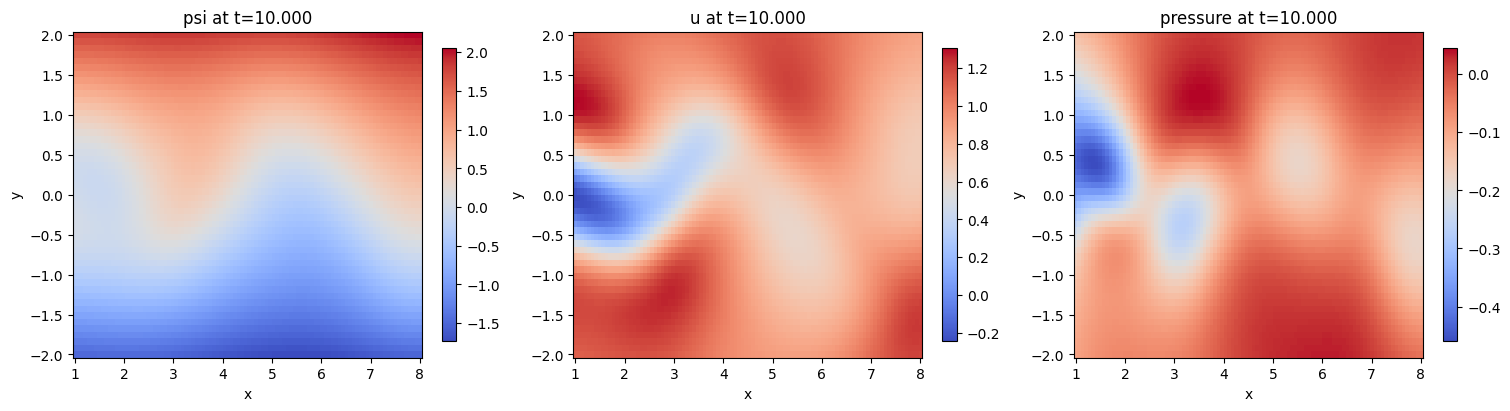

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)

fields = [
    ('psi', psi),
    ('u', u),
    ('pressure', pressure),
]

for ax, (title, values) in zip(axes, fields):
    mesh = ax.pcolormesh(x_grid, y_grid, values, shading='auto', cmap='coolwarm')
    ax.set_title(f'{title} at t={t_value:.3f}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    plt.colorbar(mesh, ax=ax, shrink=0.9)

plt.show()

## 5. Mapping: run → observation scenario

Multiple runs share the same observation (different loss weights, same noisy/biased data). Use `summary.csv` to look up the scenario for a given run.

In [7]:
run_name = 'lw_0p800_gaussian_0p050'
scenario = summary.loc[summary['run_name'] == run_name, 'scenario'].iloc[0]
obs = np.load(DATA_DIR / 'DATA_observations' / f'{scenario}.npz')

print(f'{run_name} -> DATA_observations/{scenario}.npz')
print('keys:', list(obs.keys()))

lw_0p800_gaussian_0p050 -> DATA_observations/noise_gaussian_0p050.npz
keys: ['u_obs', 'v_obs']
